In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import json

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [3]:
sample_cfg = "../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json"
with open(sample_cfg,"r") as fin:
    sig_cfg = json.load(fin)
loc0 = sig_cfg[0]['location']
loc1 = sig_cfg[1]['location']
loc2 = sig_cfg[2]['location']


In [5]:
#See the quantities in the root file:
import uproot
t0 = uproot.open(loc0)['ntuples/outT']

t1 = uproot.open(loc1)['ntuples/outT']
t2 = uproot.open(loc2)['ntuples/outT']

In [6]:
# Trigger used
met_trig0=t0["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
met_trig1=t1["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
met_trig2=t2["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()

In [7]:
#Cut for m1=10
PFMET_pt0=t0["PFMET_pt"].array()

CaloMET_pt0=t0["CaloMET_pt"].array()
diff0= abs(PFMET_pt0-CaloMET_pt0)

r0=diff0/(CaloMET_pt0)
print ("Value of ratio:",r0)
cut_sig0=(r0 <0.5)


#Cut for m1=30

PFMET_pt1=t1["PFMET_pt"].array()

CaloMET_pt1=t1["CaloMET_pt"].array()
diff1= abs(PFMET_pt1-CaloMET_pt1)

r1=diff1/(CaloMET_pt1)
cut_sig1=(r1 <0.5)


#Cut for m1=50

PFMET_pt2=t2["PFMET_pt"].array()

CaloMET_pt2=t2["CaloMET_pt"].array()
diff2= abs(PFMET_pt2-CaloMET_pt2)

r2=diff2/(CaloMET_pt2)

cut_sig2=(r2 <0.5)


Value of ratio: [0.622, 0.167, 1.08, 0.0372, 0.65, 0.537, ... 0.0592, 0.207, 0.524, 0.183, 0.442]


In [8]:
pfmet_pass0 = PFMET_pt0[cut_sig0]
print (pfmet_pass0)
err_x= np.std(pfmet_pass0)
print(err_x)

met_trig_pass0 = met_trig0[cut_sig0]  
print (met_trig_pass0)
err_y = np.std(met_trig_pass0)
print(err_y)

[59.8, 139, 55.3, 135, 145, 95.8, 121, 147, ... 85.2, 180, 72.4, 36.9, 152, 125, 177]
53.909295648618475
[False, False, False, False, False, False, ... False, False, False, False, True]
0.4432109373835696


[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.50150150e-03 8.54700855e-04 3.78787879e-03 4.69630557e-03
 9.37426764e-03 2.30129569e-02 5.44918999e-02 1.04108047e-01
 2.15540970e-01 3.59756098e-01 5.29411765e-01 6.63161848e-01
 7.85198556e-01 8.83495146e-01 9.27525622e-01 9.61015413e-01
 9.72350230e-01 9.91404011e-01 9.93288591e-01 9.95633188e-01
 9.97237569e-01 9.96710526e-01 1.00000000e+00 1.00000000e+00
 9.88165680e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 9.89795918e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00]
std: 0.40023790821407346


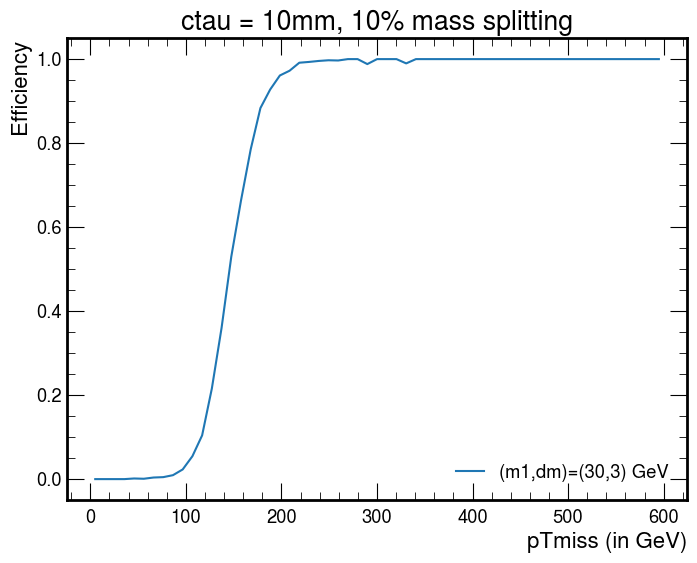

In [10]:
#Aim: To plot the trigger efficiency

pfmet_pass0 = PFMET_pt0[cut_sig0]
met_trig_pass0 = met_trig0[cut_sig0]  

pfmet_pass1 = PFMET_pt1[cut_sig1]
met_trig_pass1 = met_trig1[cut_sig1]  

pfmet_pass2 = PFMET_pt2[cut_sig2]
met_trig_pass2 = met_trig2[cut_sig2]  


bins = np.linspace(0, 600, 60)  

# deno0, edges_deno0 = np.histogram(pfmet_pass0, bins=bins)  #Denominator: the ptmiss values that pass the cut
# nume0, edges_nume0 = np.histogram(pfmet_pass0[met_trig_pass0], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
# eff_y0= np.divide(nume0, deno0)
# # print(eff_y0)
# print(np.shape(eff_y0))
# print("std:",np.std(eff_y0))

deno1, edges_deno1 = np.histogram(pfmet_pass1, bins=bins)  #Denominator: the ptmiss values that pass the cut
nume1, edges_nume1 = np.histogram(pfmet_pass1[met_trig_pass1], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
eff_y1= np.divide(nume1, deno1)
print (eff_y1)
print ("std:", np.std(eff_y1))

# deno2, edges_deno2 = np.histogram(pfmet_pass2, bins=bins)  #Denominator: the ptmiss values that pass the cut
# nume2, edges_nume2 = np.histogram(pfmet_pass2[met_trig_pass2], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
# eff_y2= np.divide(nume2, deno2)


pfmet_pass_bin_x=0.5 * (edges_deno1[:-1] + edges_deno1[1:])
# #print (pfmet_bin_x)

plt.figure(figsize=(8,6))
# #plt.plot(pfmet_pass_bin_x,eff_y0, label='(m1,dm)=(10,1) GeV')
# #plt.errorbar(x, y, yerr = np.std(eff_y1), fmt ='o')
# plt.errorbar(pfmet_pass_bin_x,eff_y1, yerr = np.std(eff_y1), fmt = 'o')
plt.plot(pfmet_pass_bin_x,eff_y1, label='(m1,dm)=(30,3) GeV')

plt.xlabel("pTmiss (in GeV)")  
plt.ylabel("Efficiency")
plt.title("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("trigger_eff.png")


In [ ]:
bins = np.linspace(0, 600, 60)  

#Numerator error:
met_trig_pass2 = met_trig2[cut_sig2]  
std_num, bin_edges_num, binnumber_num = binned_statistic(pfmet_pass2[met_trig_pass2],pfmet_pass2[met_trig_pass2] , statistic='std', bins=bins)
print (pfmet_pass2[met_trig_pass2])
print ("std_num:", std_num)


#Denominator error:
pfmet_pass2 = PFMET_pt2[cut_sig2]
std_den, bin_edges_den, binnumber_den = binned_statistic(pfmet_pass2, pfmet_pass2, statistic='std', bins=bins)
#print ("std_den:", std_den)

#Efficiency calculation:
nume2, edges_nume2 = np.histogram(pfmet_pass2[met_trig_pass2], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
deno2, edges_deno2 = np.histogram(pfmet_pass2, bins=bins)  #Denominator: the ptmiss values that pass the cut
eff_y2= np.divide(nume2, deno2)

#Efficiency error:
unc_eff = (eff_y2)*(np.sqrt((std_num/nume2)**2 + (std_den/deno2)**2))
for location, i in enumerate(unc_eff):
    if (i>0.3):
        print (location,i)
    

pfmet_pass_bin_x=0.5 * (edges_deno2[:-1] + edges_deno2[1:])
plt.errorbar(pfmet_pass_bin_x, eff_y2, unc_eff, fmt ='o',label='(m1,dm)=(50,5) GeV')


plt.xlabel("pTmiss (in GeV)")  
plt.ylabel("Efficiency")
plt.title("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("trigger_eff.png")


In [ ]:
bins = np.linspace(0, 600, 60)  

pfmet_pass2 = PFMET_pt[cut_sig1]
std_num, bin_edges_num, binnumber_num = binned_statistic(pfmet_pass1, pfmet_pass1, statistic='std', bins=bins)
print ("std_num:", std_num)


met_trig_pass1 = met_trig1[cut_sig1]  
std_den, bin_edges_den, binnumber_den = binned_statistic(pfmet_pass1[met_trig_pass1],pfmet_pass1[met_trig_pass1] , statistic='std', bins=bins)
print ("std_den:", std_den)


deno1, edges_deno1 = np.histogram(pfmet_pass1, bins=bins)  #Denominator: the ptmiss values that pass the cut
nume1, edges_nume1 = np.histogram(pfmet_pass1[met_trig_pass1], bins=bins) #Numerator: the ptmiss values that pass the MET tigger and the cut applied
eff_y1= np.divide(nume1, deno1)
#print (eff_y1)

unc_eff = (1/deno1) * (np.sqrt((std_num)**2 + ((eff_y1)**2) * (std_den)**2))

print (unc_eff)

pfmet_pass_bin_x=0.5 * (edges_deno1[:-1] + edges_deno1[1:])
plt.errorbar(pfmet_pass_bin_x, eff_y1, unc_eff, fmt ='o',label='(m1,dm)=(10,1) GeV')


plt.xlabel("pTmiss (in GeV)")  
plt.ylabel("Efficiency")
plt.title("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("trigger_eff.png")


# σE = (1/D) * np.sqrt(σN**2 + (E**2) * σD**2)
